# Ch08-3 합성곱 신경망의 시각화

keras의 sequential 말고도 다른 함수형 API를 사용해보자

## 1. 가중치 시각화

합성곱 층은 여러 개의 필터를 사용해 이미지에서 특징을 학습한다.         
각 필터는 커널이라고 하는 가중치와 절편을 가지고 있다.      
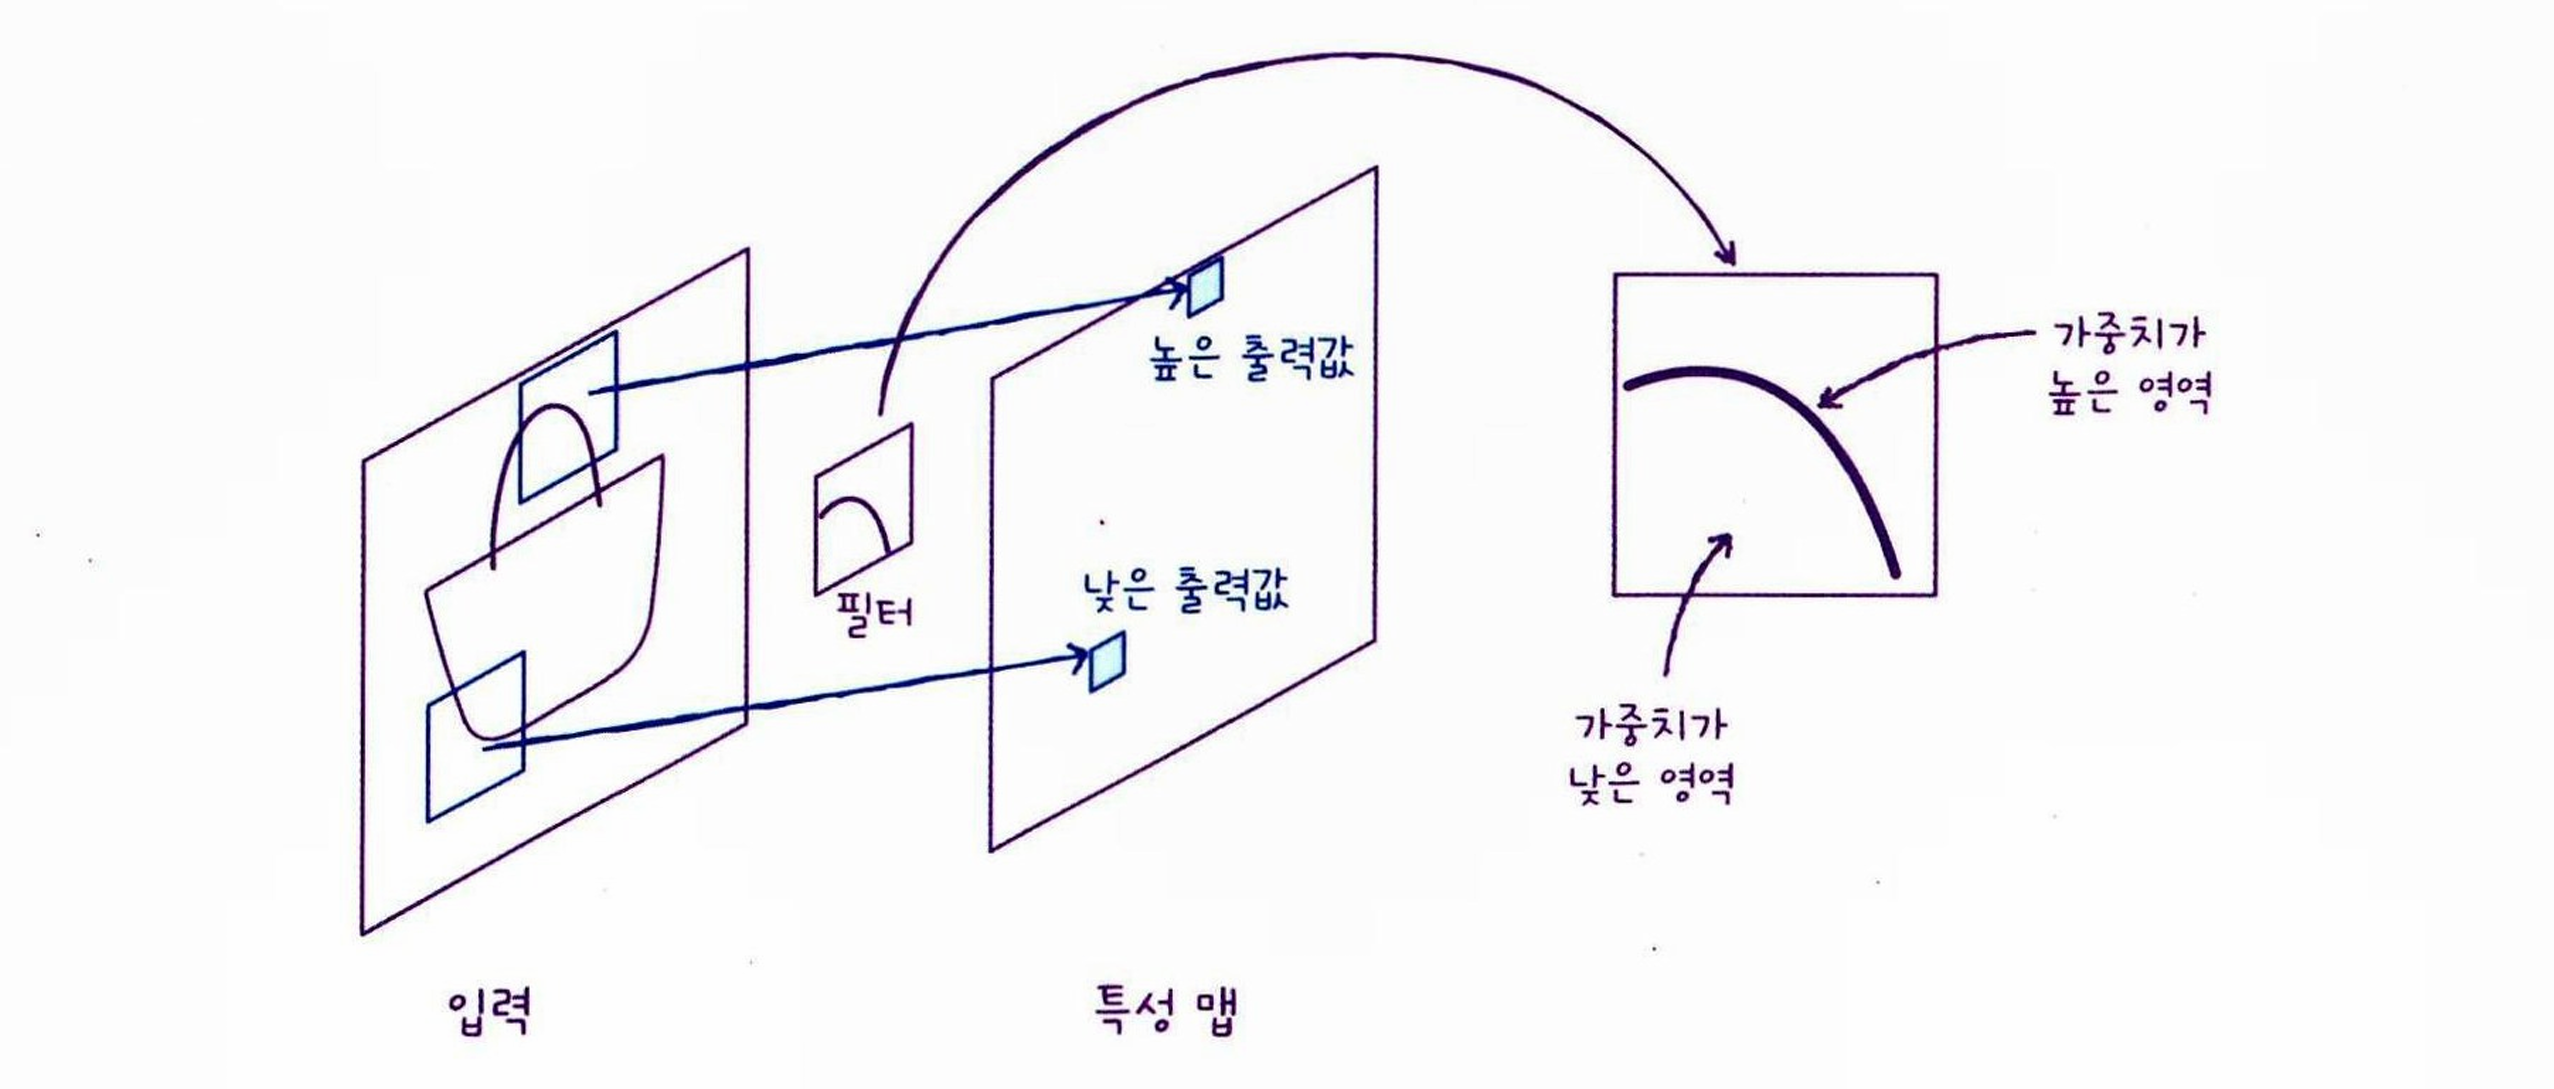

**가중치 시각화(weight visualization) =**           
CNN의 필터(커널)가 이미지에서 어떤 특징을 강하게 보는지 눈으로 확인하는 것.         

만약, 둥근 모양을 탐지하는 필터라면,        
        - 둥근 모양이 있을 때 큰 값 (활성화)
        - 없을 때 작은 값 (비활성화)

In [1]:
import keras
model = keras.models.load_model('best-cnn-model.keras')

2025-11-27 17:27:03.384270: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 17:27:03.425446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764232023.460024  183987 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764232023.469503  183987 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 17:27:03.521550: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [3]:
#첫 번째 합성곱 층의 가중치를 조사해보기
# 층의 가중치와 절편은 층의 weights 속성에 저장되어있음
# weights 도 파이썬 리스트 

conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


커널 크기 (3,3)      합성곱 층에 전달되는 입력의 깊이 ` => 실제 커널 크기 (3, 3, 1)     
필터 개수 32개 -> weights의 원소인 가중치의 크기 = (3, 3, 1, 32)        
두 번째 원소는 절편의 개수 = (32, )

In [6]:
conv_weights = conv.weights[0].numpy() #넘파이 배열로 변환
print(conv_weights.mean(), conv_weights.std()) #가중치배열의 평균과 표준편차 계산

-0.025659334 0.25830615


평균 값은 0에 가깝고, 표준 편차는 0.25 정도.        
나중에 이 값을 훈련 전 가중치와 비교

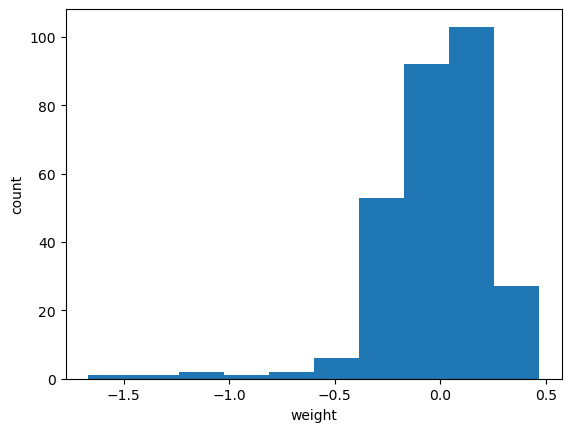

In [ ]:
#히스토그램 그리기
import matplotlib.pyplot as plt 

plt.hist(conv_weights.reshape(-1, 1)) #히스토그램을 그리기 위해 1차원 배열로 변환
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

0을 중심으로 종 모양

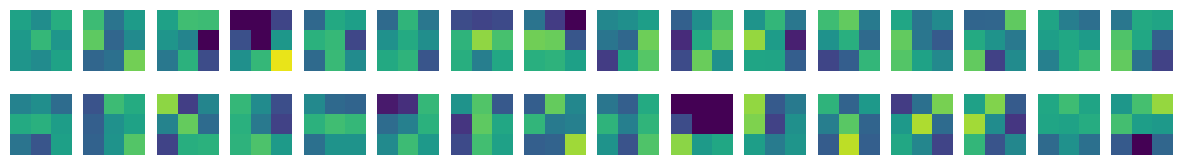

In [ ]:
#32개 커널을 16개씩 두 줄에 출력해보기 

fig, axs = plt.subplots(2, 16, figsize=(15, 2)) #2행 16열의 그림 격자
for i in range(2): #2줄
    for j in range(16) : #16칸 반복문으로 32개 필터 하나씩 꺼내서 그림으로 표시
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax =0.5)
        axs[i,j].axis('off') #축(테두리, 눈금) 지우기
plt.show()

Conv2D의 가중치(conv_weights)는 보통 다음과 같이 저장됨:        
`(height, width, input_channels, filter_index)`

**filter_index: i*16 + j로 지정**       
즉,
|i	|j|	i*16 + j	|의미
|---|---|---|---
|0|	0|	0	|1번째 필터
|0|	15|	15|	16번째 필터
|1	|0	|16|	17번째 필터
|1|	15|	31|	32번째 필터

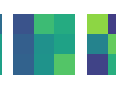
왼쪽이 상대적으로 낮은 값 (어두움 )     


`imshow()`함수는 배열에 있는 최댓값과 최솟값을 사용해 픽셀의 강도를 표현.       
즉, 0.1이나 0.4나 어떤 값이든 그 배열의 최댓값이면 가장 밝은 노란색으로 그림.       
따라서 ,두 배열을 `imshow()`함수로 비교하는 것은 바람직 하지 않음           

`vmin=-0.5, vmax =0.5` 를 통해 컬러 맵으로 표현할 범위를 지정한 것 .        


### 훈련하지 않은 빈 합성곱 신경망을 만들어서 보기.

In [ ]:
no_training_model = keras.Sequential() # 모델 생성
no_training_model.add(keras.layers.Input(shape=(28, 28,1))) 
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation=\ 
    'relu', padding= 'same'))#한 줄 띄어야 함



**왜 =\ 하고 밑으로 줄을 내리지?**
파이썬에서 \ 는 아직 이 줄이 안끝났다는 뜻.     
즉. 원래는 `no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))` 인데,     
줄바꿈을 하기 위해 표시 

In [12]:
#첫 번째 층 (Conv@d 층)의 가중치를 no_training_conv 변수에 저장  
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


(3,3) 커널을 가진 필터를 32개 사용했으므로 가중치의 크기 동일

In [14]:
#넘파이 배열로 만든 다음, 평균, 표준편차 
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

-0.0065253805 0.08302907


위에서는 (-0.025659334 0.25830615)          
지금은 (-0.0065253805 0.08302907)           

표준편차가 매우 작게 됨

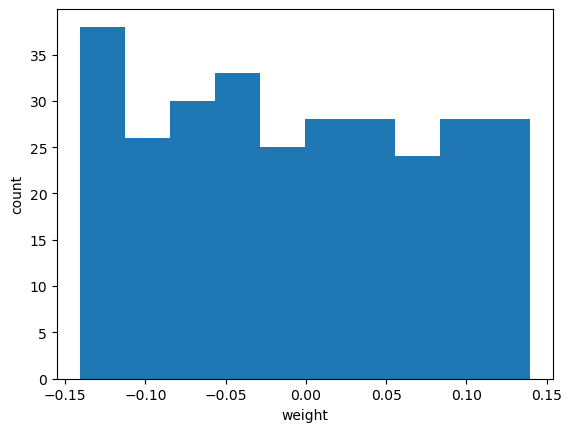

In [15]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

이전과 다르게 대부분의 가중치가 -0.15~0.15 사이에 있고, 비교적 고른 분포        

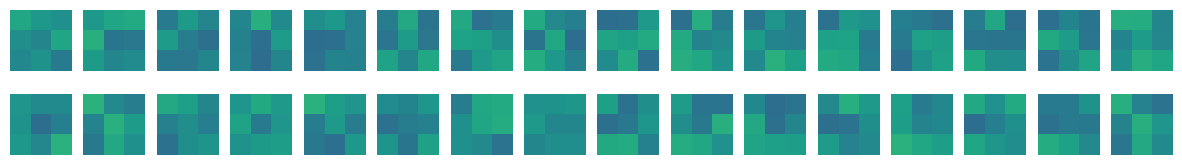

In [16]:
#imshow를 사용해 그림으로 출력, 
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i,j].axis('off')
plt.show()

밋밋한 가중치로 초기화 

## 2. 함수형 API

`Sequential` 클래스는 층을 차례대로 쌓은 모델을 만든다. 
그러나, 딥러닝에는 입력이 2갱리 수도, 출력이 2개일 수도 있다.       
이런 경우에는 함수형 API를 사용한다.        

`Model`클래스를 사용하여 모델을 만든다.

In [ ]:
#7장에서 만든 Dense층 2개로 이루어진 완전 연결 신경망을 함수형 API로 구현   
#입력층 2개의 Dense층 객체를 만들기.

inputs = keras.Input(shape=(784, )) #입력층
dense1 = keras.layers.Dense(100, activation='relu') #첫 번째 dense 층
dense2 = keras.layers.Dense(10, activation='softmax') #두 번째 dense 층
#여기까지는 레이어를 만들기만 한 상태

In [19]:
hidden = dense1(inputs)

keras의 레이어는 사실 함수처럼 동작한다.            
“inputs → dense1 레이어를 통과시켜서 hidden 출력값 만든다” 는 뜻        
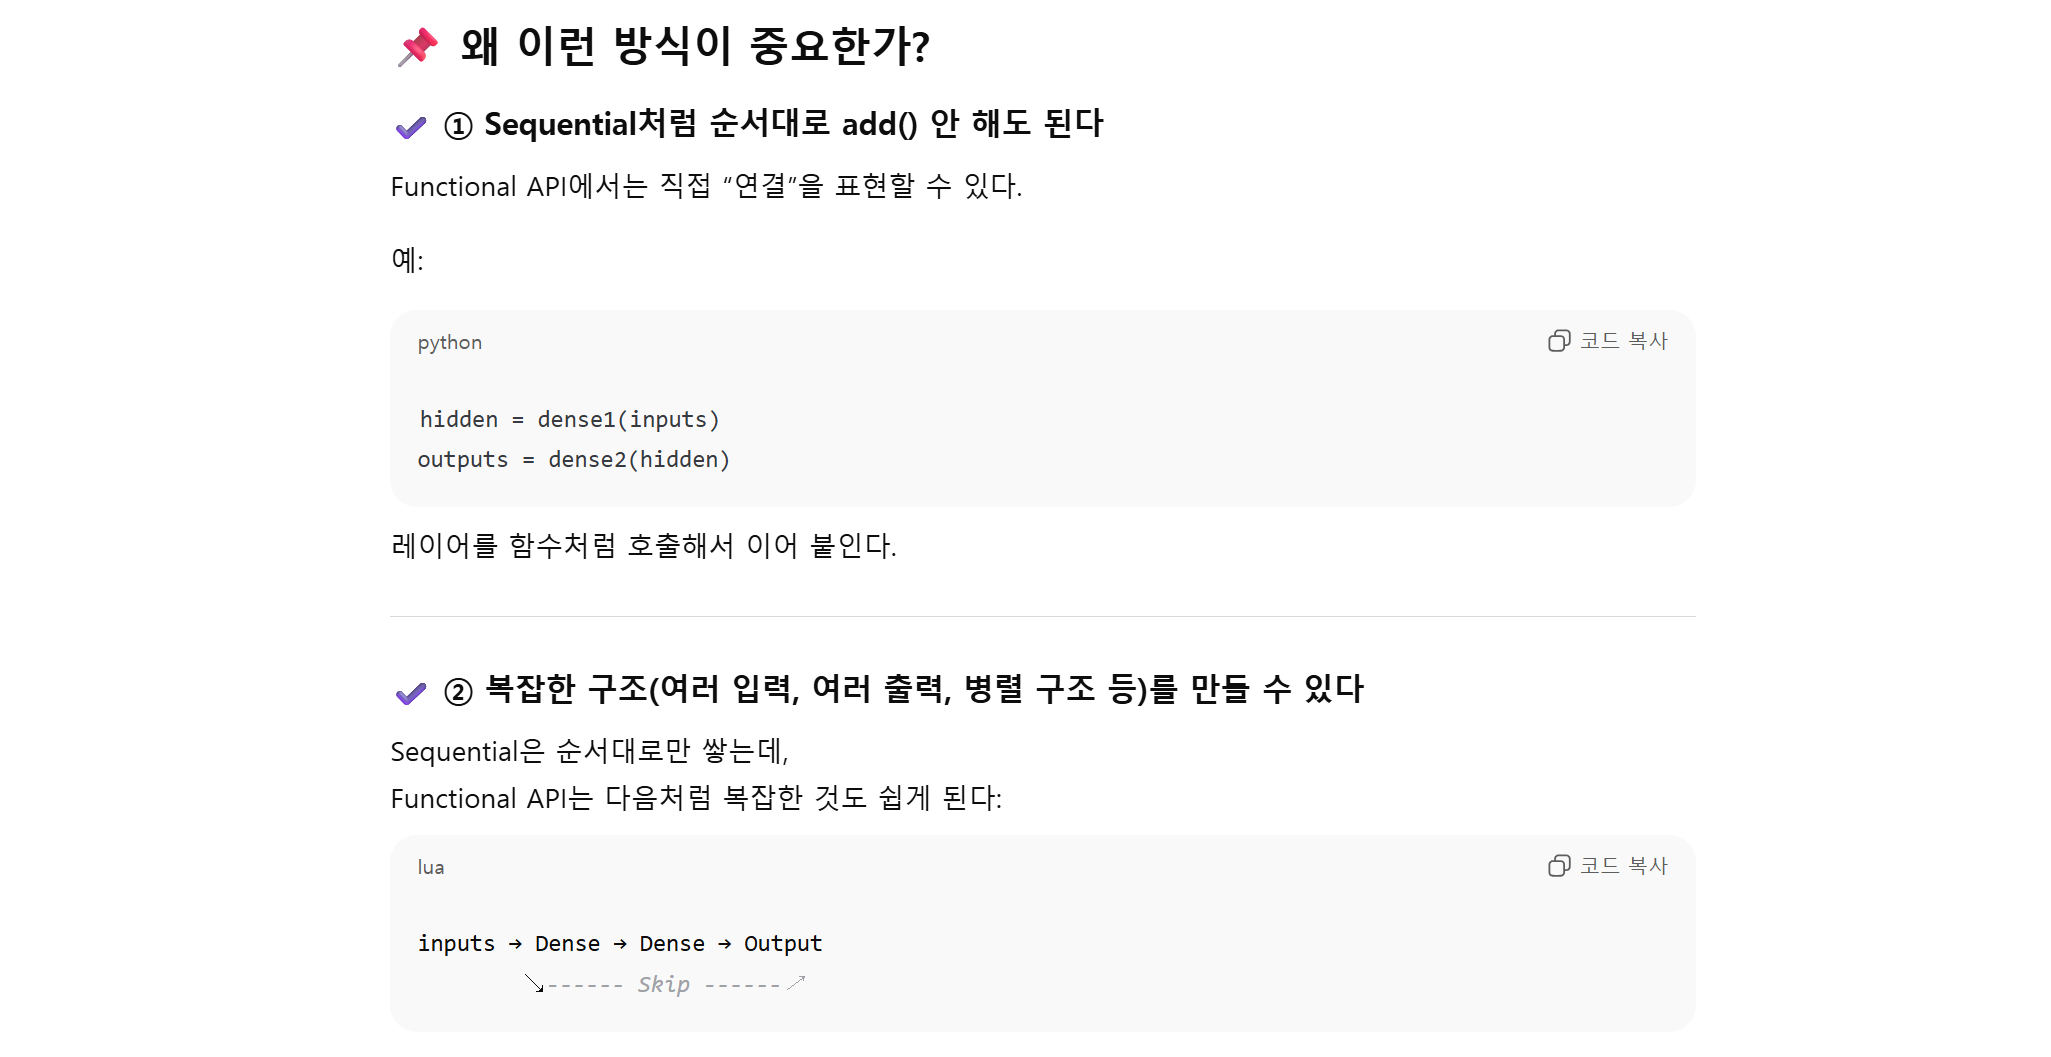

In [20]:
outputs = dense2(hidden)

In [21]:
func_model = keras.Model(inputs, outputs)

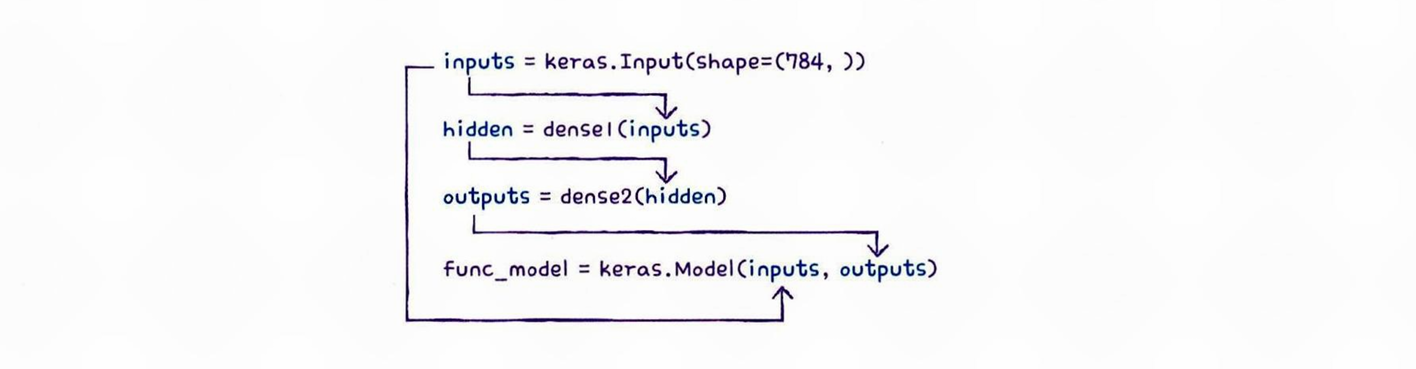

**처음 정의한 model 객체의 층을 순서대로 나열**
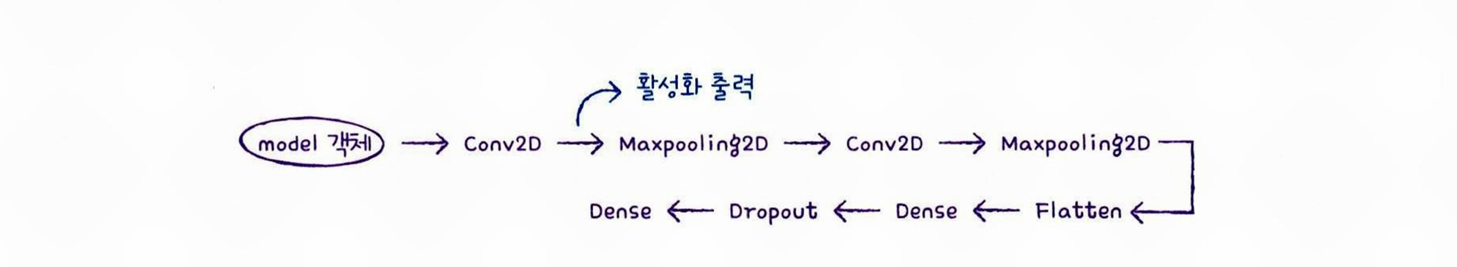
- 여기서는 전체를 다 계산한 후 최종 출력을 반환     


**모델 객체의 입력과 Conv2D의 출력을 알 수 있으면 이 것으로 새로운 모델?**
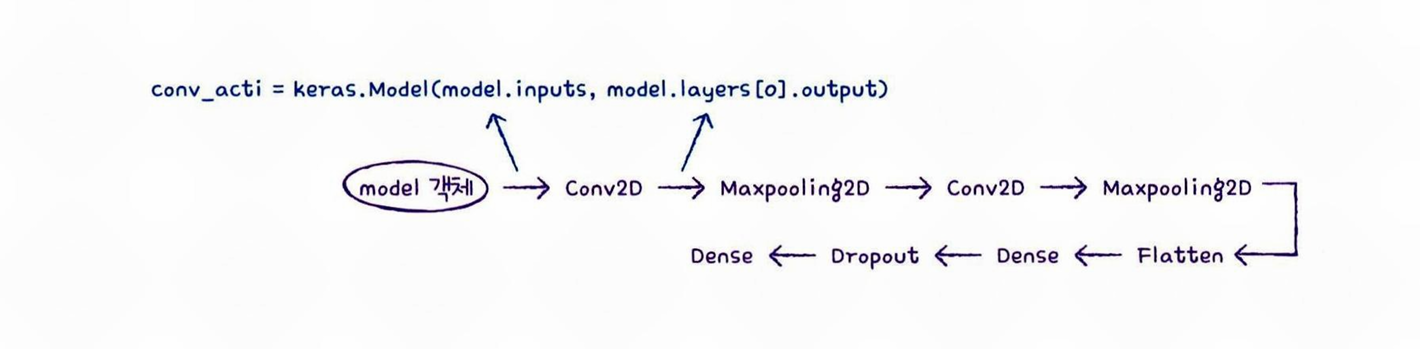

In [22]:
print(model.inputs)#모델 입력만 확인

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=input_layer>]


In [25]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output) 

model 객체의 predict()를 호출하면 최종 출력층의 확률을 반환하지만,      
conv_acti의 predict()메서드를 호출하면 첫 번째 Conv2D의 출력을 반환할 것.       

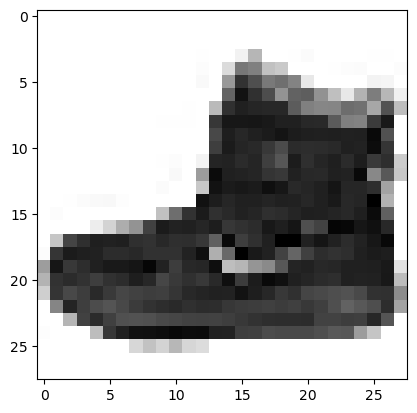

In [26]:
(train_input, train_target), (test_input, test_target)=\
    keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

### conv_acti에 주입하여 Conv2D 층이 만드는 특성 맵 출력해보기 

predict() 메서드는 항상 입력의 첫 번째 차원이 배치 차원일 것으로 기대하므로,        
하나의 샘플만 전달하더라도 꼭 첫 번째 차원을 유지해야한다.      
따라서, 슬라이싱 연산자를 사용해 첫 번째 샘플을 선택. -> 그 다음에 (28, 28)크기를 (28, 28, 1) 크기로 변경하고 255로 나눔


In [27]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)


I0000 00:00:1764240535.599970  184130 service.cc:148] XLA service 0x7151e8002f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764240535.601387  184130 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 4GB Laptop GPU, Compute Capability 8.6
2025-11-27 19:48:55.679535: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764240535.762429  184130 cuda_dnn.cc:529] Loaded cuDNN version 91501


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1764240537.268204  184130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [28]:
#feature_maps 크기 확인
print(feature_maps.shape)

(1, 28, 28, 32)


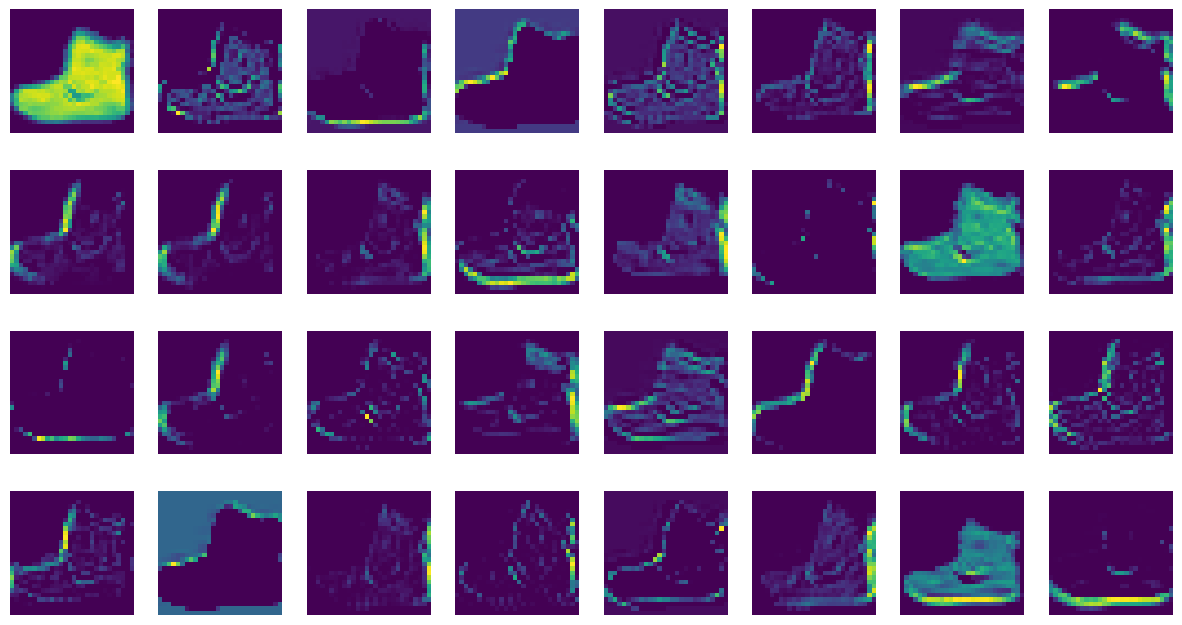

In [30]:
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 +j])
        axs[i, j].axis('off')
plt.show()

In [31]:
#두 번째 합성곱 층이 만든 특성맵 확인
# model 객체의 입력과 두 번째 합성곱 층인 model.layers[2]의 출력을 연결한 conv2_acti 모델 만들기
conv2_acti =keras.Model(model.inputs[0], model.layers[2].output)

In [32]:
#앵클 부츠 샘플을 conv2_acti모델의 predict() 메서드에 전달
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step


In [33]:
#첫 번째 풀링 층에서 가로세로 크기 절반으로, 두 번째 합성곱 층의 필터 개수는 64개이므로 
print(feature_maps.shape)

(1, 14, 14, 64)


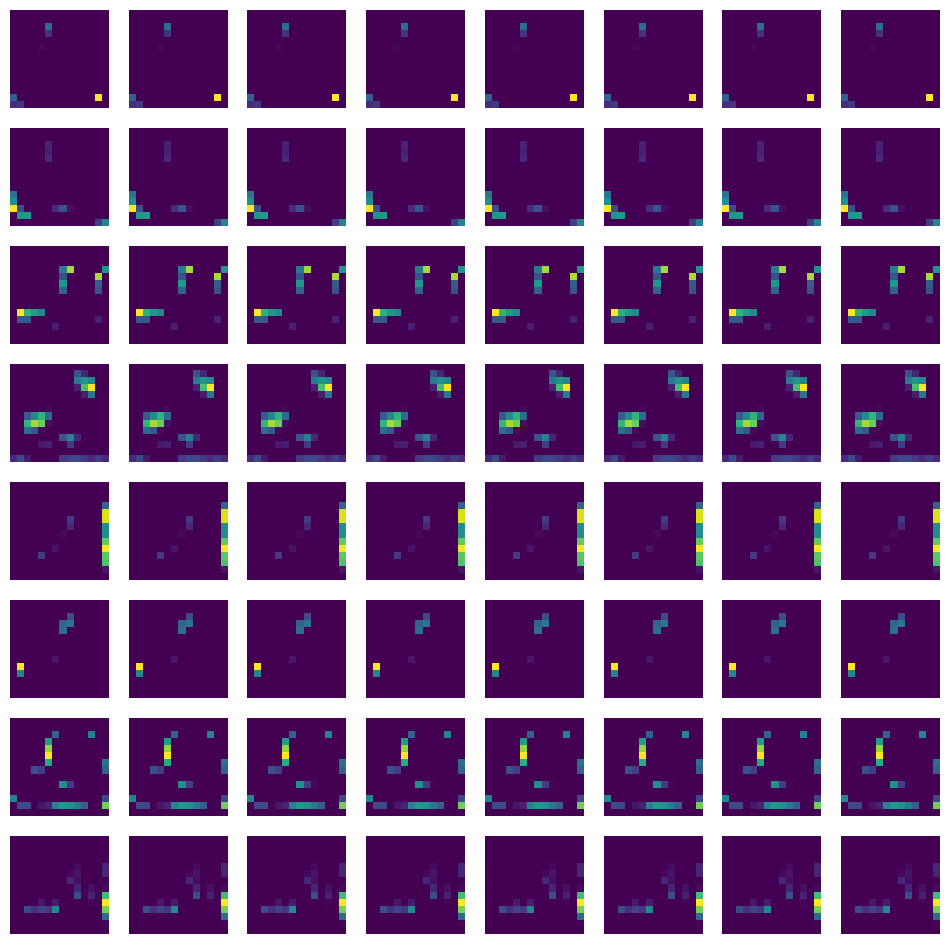

In [34]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8): 
    for j in range(8) :
        axs[i, j].imshow(feature_maps[0,:,:,i*8]+j)
        axs[i, j].axis('off')
plt.show()

첫 번째 합성곱 층과 겹쳐서 쌓였기 때문에 어두어 짐.     

즉, 합성곱 신경망의 앞부분에 위치한 합성곱 층은 이미지의 시각적인 정보를 감지하고,      
뒤 쪽에 있는 합성곱 층은 앞쪽에서 감지한 시각적인 정보를 바탕으로 추상적인 정보를 학습한다.     

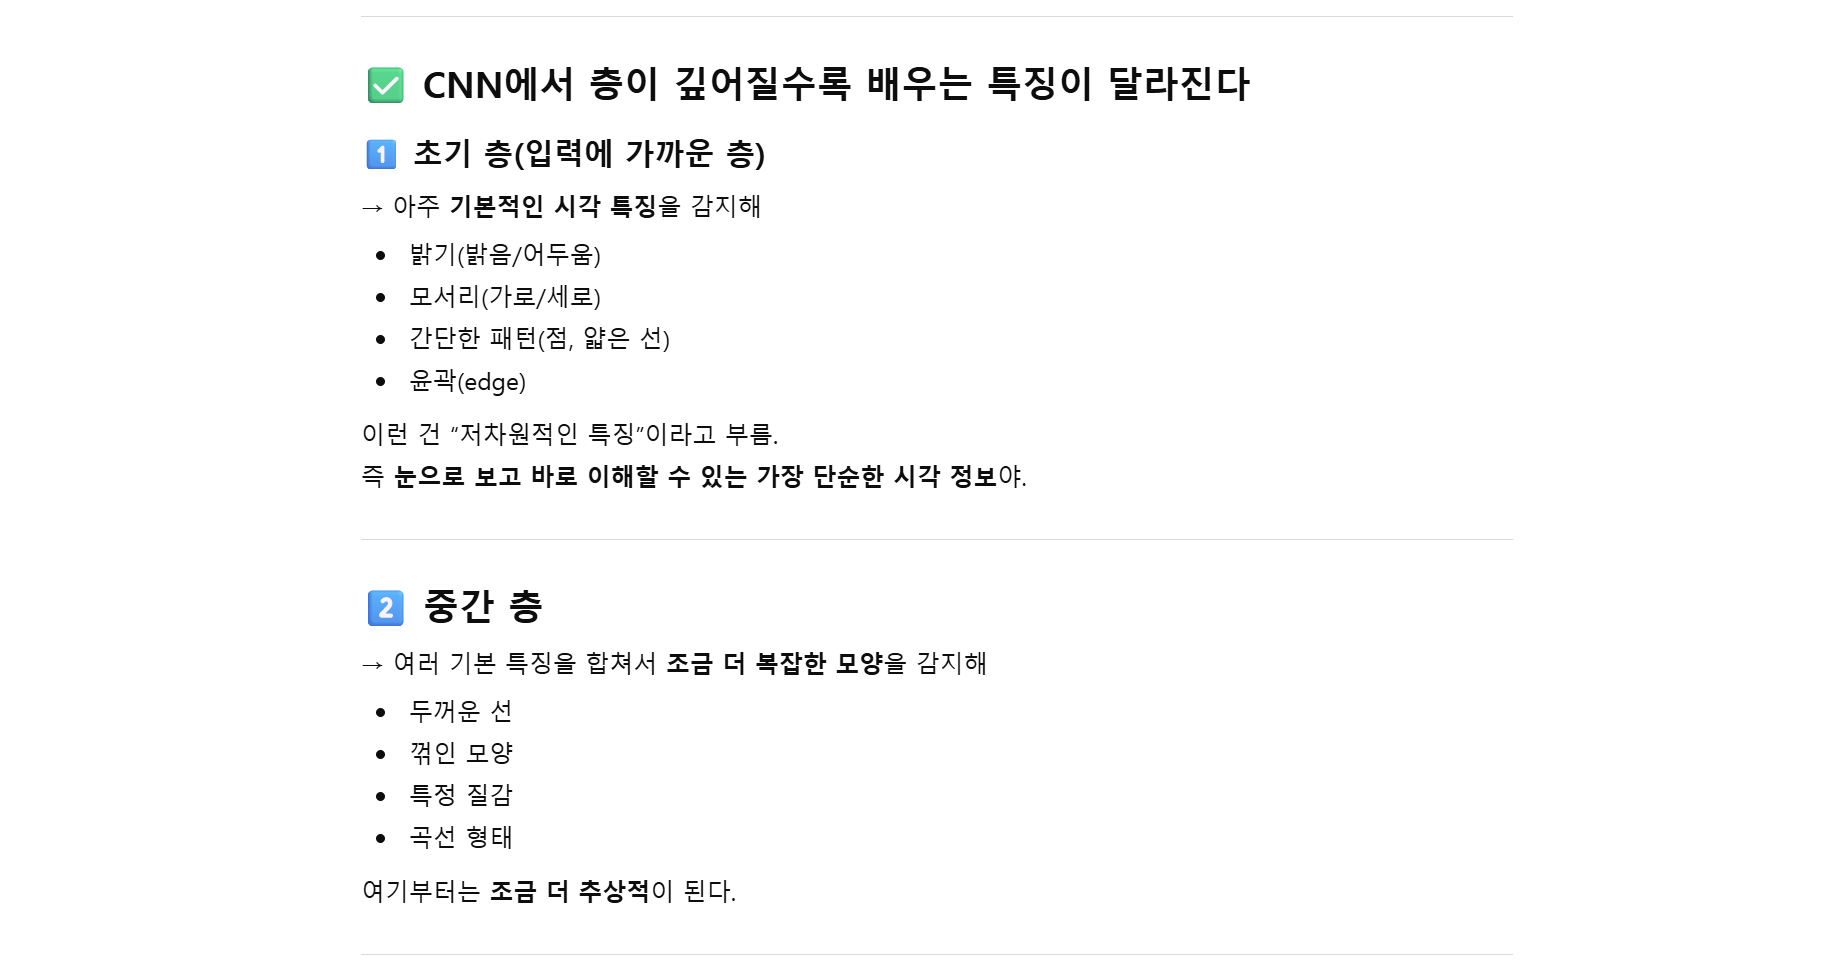
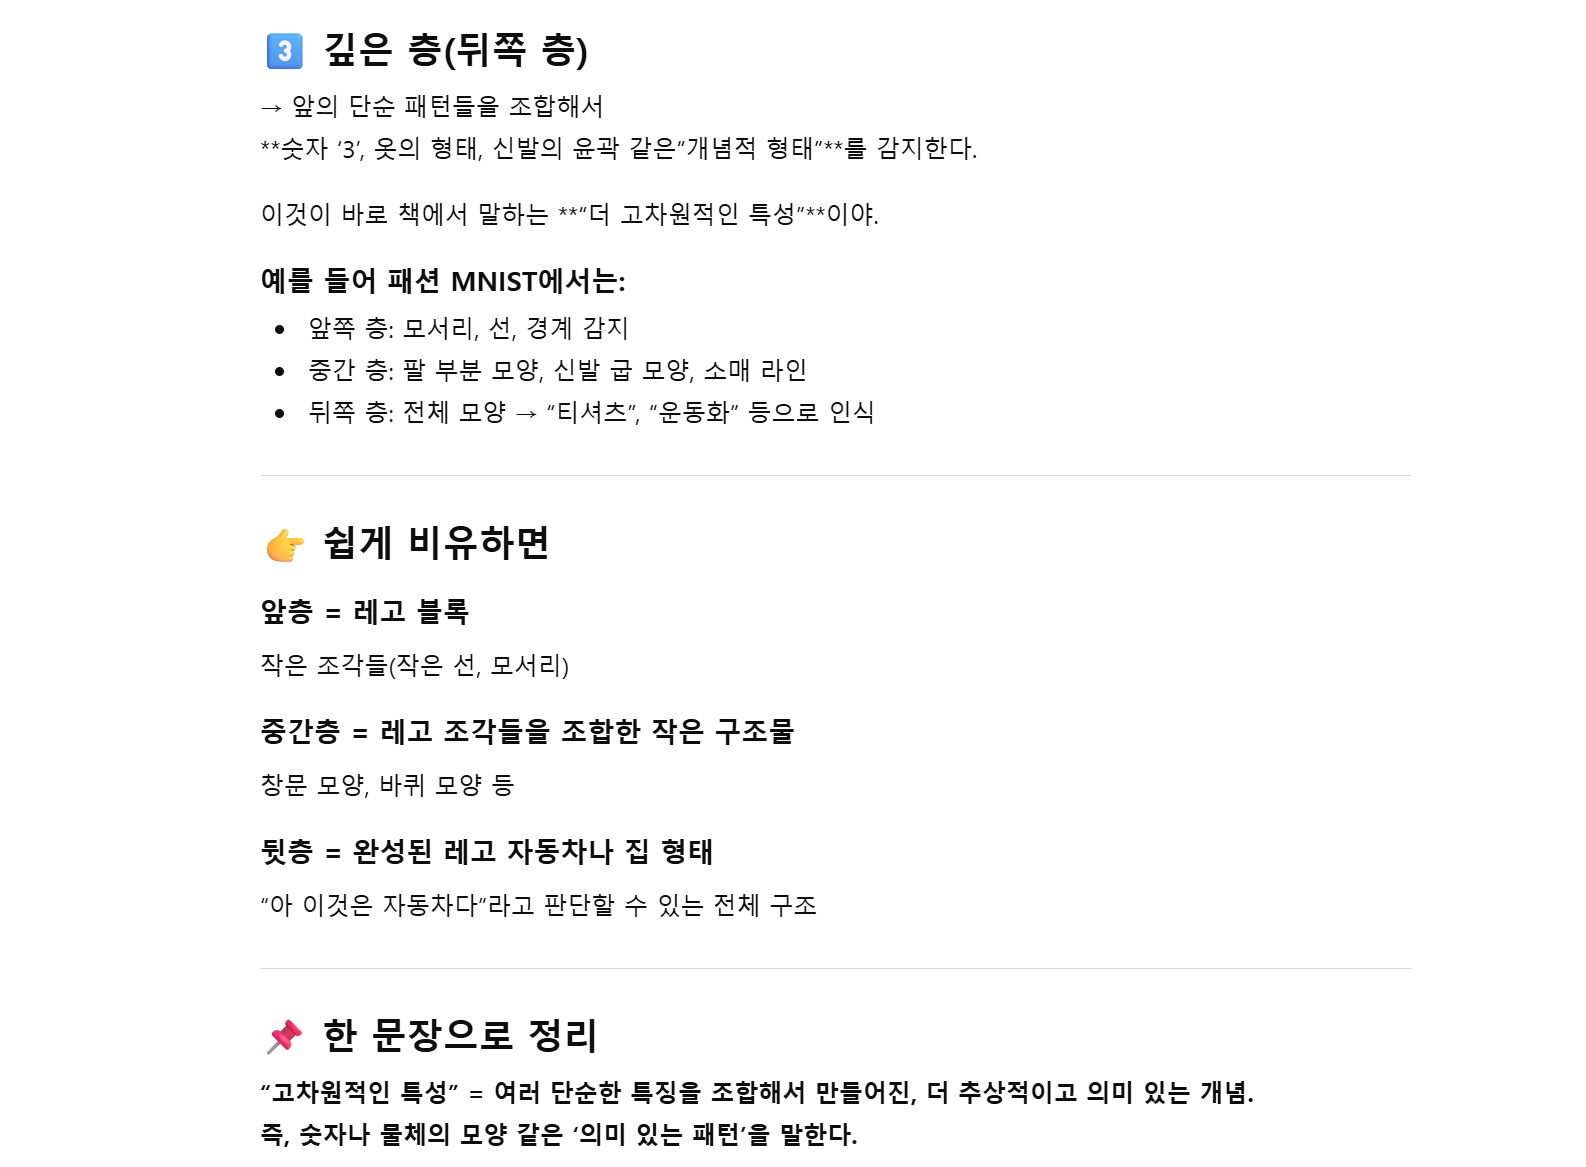